# Description

This dataset was downloaded from [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn?resource=download).
It contains public customer data from the __TELCO__ company.
The goal is to predict the behavior of customers in the future, i.e. whether they will "churn" (leave TELCO as a customer in the last month) or not.
For this, we can use a 21 column table containing features of 7043 customers.
In this notebook, we will explore the dataset, look for internal dependencies (correlations), data distribution and normality, and create visualizations.

# Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr

from sklearn.metrics import RocCurveDisplay

Load in the `.csv` file and take some basic look at the data, columns and column types and descriptive statistics.

In [2]:
raw_data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
raw_data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
raw_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Look for categorical columns and print out the possible categories for these.

In [5]:
categorical_columns = dict()
for column_name in raw_data.columns:

    column_dtype = str(raw_data[column_name].dtype)
    print(f"\n{column_name} has a dtype of {column_dtype}...")

    if column_dtype in {"int64", "float64"}:
        continue

    unique_values = np.unique(raw_data[column_name])

    if len(unique_values) > 20:
        print(f"--- WARNING: {column_name} is non-numeric, but has more than 20 ({len(unique_values)}) categories!")
    else:
        print(f"--- {column_name} has the following unique values:\n\t{'\n\t'.join(map(str, unique_values))}")

        # Save category occurrence information for categorical columns.
        categorical_columns[column_name] = {
            uv: np.mean(raw_data[column_name] == uv)
            for uv in unique_values
        }


customerID has a dtype of object...
--- WARNING: customerID is non-numeric, but has more than 20 (7043) categories!

gender has a dtype of object...
--- gender has the following unique values:
	Female
	Male

SeniorCitizen has a dtype of int64...

Partner has a dtype of object...
--- Partner has the following unique values:
	No
	Yes

Dependents has a dtype of object...
--- Dependents has the following unique values:
	No
	Yes

tenure has a dtype of int64...

PhoneService has a dtype of object...
--- PhoneService has the following unique values:
	No
	Yes

MultipleLines has a dtype of object...
--- MultipleLines has the following unique values:
	No
	No phone service
	Yes

InternetService has a dtype of object...
--- InternetService has the following unique values:
	DSL
	Fiber optic
	No

OnlineSecurity has a dtype of object...
--- OnlineSecurity has the following unique values:
	No
	No internet service
	Yes

OnlineBackup has a dtype of object...
--- OnlineBackup has the following unique va

In [6]:
len(categorical_columns)

16

It seems like that the "TotalCharges" column is problematic, because it should be numeric, but is recognized as an object dtype column. Let's try to convert values to floats, but if conversion fails, store the failed elements in a list.

In [7]:
failed_total_charges_conversions = list()
for value in raw_data["TotalCharges"]:
    try:
        _ = float(value)
    except:
        failed_total_charges_conversions.append(value)
print(f"Number of failed to convert elements: {len(failed_total_charges_conversions)}")
print(f"Enumerated: {'\n- '.join(map(str, failed_total_charges_conversions))}")

Number of failed to convert elements: 11
Enumerated:  
-  
-  
-  
-  
-  
-  
-  
-  
-  
-  


It seems like that 11 times only a widespace is present in that column. This means that we can place `NaN` values to these places and convert the other ones to floats.

In [8]:
raw_data["TotalCharges"] = raw_data["TotalCharges"].map(lambda x: float(x) if x != " " else float("NaN"))

In [9]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
raw_data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


The senior citizen column is also categorical, since it only contains 0 or 1 values. It did not get into the `categorical_columns` dictionary, because it is already binary encoded and recognized as a numerical column. Let's add it manually to the dictionary!

In [11]:
categorical_columns["SeniorCitizen"] = {
    uv: np.mean(raw_data["SeniorCitizen"] == uv)
    for uv in [0, 1]
}
print(categorical_columns["SeniorCitizen"])
print(len(categorical_columns))

{0: np.float64(0.8378531875621185), 1: np.float64(0.1621468124378816)}
17


# Statistical Analysis and Visualizations

Take a look at the percentages of the categories in the categorical columns.

In [12]:
for column_name, percentages in categorical_columns.items():
    print(f"{column_name}: ", end="")
    for uv, p in percentages.items():
        print(f"{uv} ({p:.1%})", end=" ")
    print()

gender: Female (49.5%) Male (50.5%) 
Partner: No (51.7%) Yes (48.3%) 
Dependents: No (70.0%) Yes (30.0%) 
PhoneService: No (9.7%) Yes (90.3%) 
MultipleLines: No (48.1%) No phone service (9.7%) Yes (42.2%) 
InternetService: DSL (34.4%) Fiber optic (44.0%) No (21.7%) 
OnlineSecurity: No (49.7%) No internet service (21.7%) Yes (28.7%) 
OnlineBackup: No (43.8%) No internet service (21.7%) Yes (34.5%) 
DeviceProtection: No (43.9%) No internet service (21.7%) Yes (34.4%) 
TechSupport: No (49.3%) No internet service (21.7%) Yes (29.0%) 
StreamingTV: No (39.9%) No internet service (21.7%) Yes (38.4%) 
StreamingMovies: No (39.5%) No internet service (21.7%) Yes (38.8%) 
Contract: Month-to-month (55.0%) One year (20.9%) Two year (24.1%) 
PaperlessBilling: No (40.8%) Yes (59.2%) 
PaymentMethod: Bank transfer (automatic) (21.9%) Credit card (automatic) (21.6%) Electronic check (33.6%) Mailed check (22.9%) 
Churn: No (73.5%) Yes (26.5%) 
SeniorCitizen: 0 (83.8%) 1 (16.2%) 


Calculate crosstabs for all categorical columns against the target column (Churn). Normalize crosstabs along the columns, which creates marginalized probabilities `P(Churn | column value)` telling us the probability that a customer will leave given its categorical value. Only print out a crosstab if the rowwise min-max gap is greater than a 20% threshold.

In [13]:
for column_name in categorical_columns:

    if column_name == "Churn":
        continue

    crosstab = pd.crosstab(index=raw_data["Churn"], columns=raw_data[column_name], normalize="columns")
    gap = (crosstab.max(axis=1) - crosstab.min(axis=1))["Yes"]

    if gap > 0.2:
        print(crosstab, f"\n{gap=:.3%}\n")

InternetService       DSL  Fiber optic       No
Churn                                          
No               0.810409     0.581072  0.92595
Yes              0.189591     0.418928  0.07405 
gap=34.488%

OnlineSecurity        No  No internet service       Yes
Churn                                                  
No              0.582333              0.92595  0.853888
Yes             0.417667              0.07405  0.146112 
gap=34.362%

OnlineBackup        No  No internet service       Yes
Churn                                                
No            0.600712              0.92595  0.784685
Yes           0.399288              0.07405  0.215315 
gap=32.524%

DeviceProtection        No  No internet service       Yes
Churn                                                    
No                0.608724              0.92595  0.774979
Yes               0.391276              0.07405  0.225021 
gap=31.723%

TechSupport        No  No internet service       Yes
Churn                      

There are already some pretty good predictors for churning; the printed crosstabs all represent features, which alone can separate churning and non-churning customers with a margin of 20%. The "Contract" feature contains the largest gap; if a customer has a two-year contract type, then it churns only 3% of the time. In contrast, if a customer has a month-to-month contract type, it churns 43% of the time.

Now, take a look at the numeric columns.

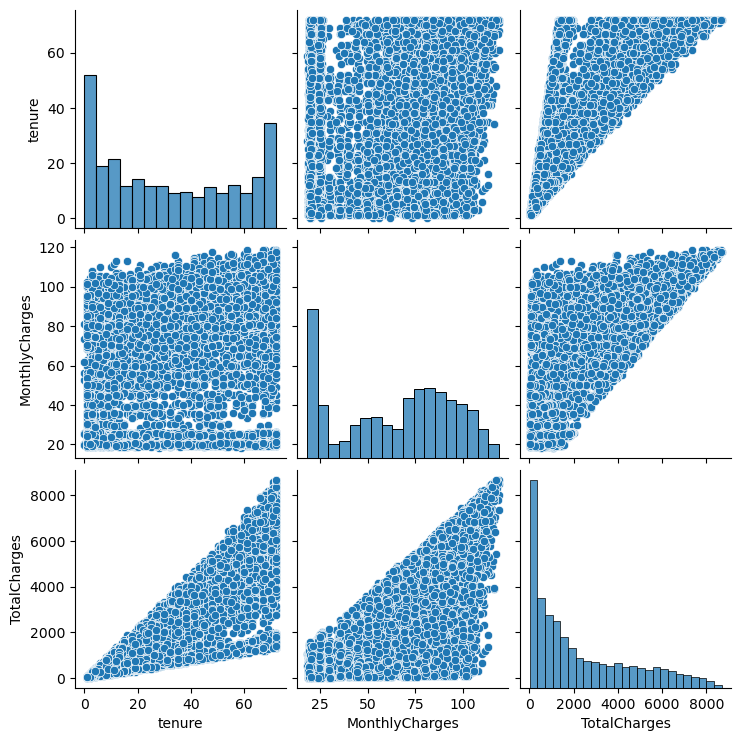

In [14]:
sns.pairplot(raw_data[["tenure", "MonthlyCharges", "TotalCharges"]])

These look informative; it seems like that the total charge a customer has to pay is capped linearly from below and from above according to the tenure value. The tenure value describes for how long the customer has been with TELCO. In contrast, the limit of monthly charges is not dependent on the tenure. 

While the distribution of the tenure value is pretty uniform, the distribution of the monthly charges is multimodal and the total charges are distributed more like an exponential or power-law distribution.

Let's take a look at the relationship of these with the churn column.

[<Axes: xlabel='tenure', ylabel='Density'>,
 <Axes: xlabel='MonthlyCharges', ylabel='Density'>,
 <Axes: xlabel='TotalCharges', ylabel='Density'>]

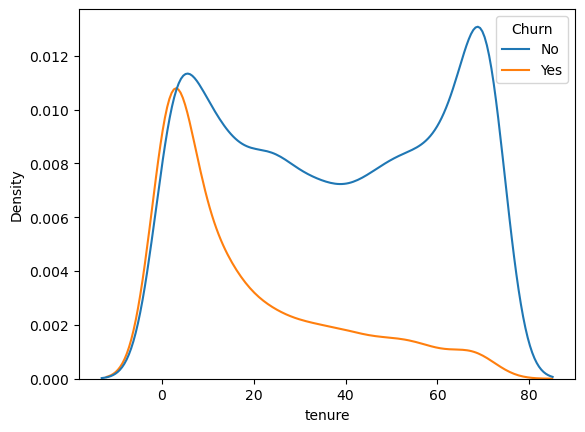

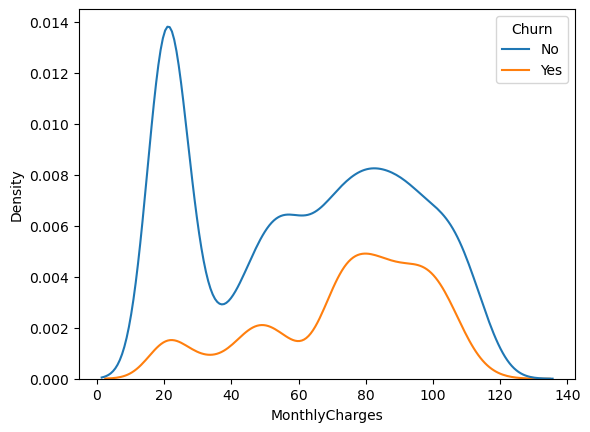

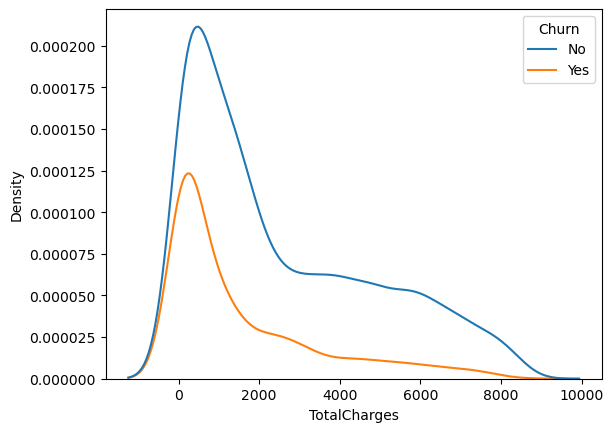

In [15]:
churn_vs_numeric = list()
for column_name in ["tenure", "MonthlyCharges", "TotalCharges"]:
    fig, ax = plt.subplots()
    current_plot = sns.kdeplot(raw_data, x=column_name, hue="Churn", ax=ax)
    churn_vs_numeric.append(current_plot)
churn_vs_numeric

The tenure and monthly charges columns are very good indicators for customer churning. A high tenure value or a low monthly charge value will make churning less likely. And since, according to the scatter plots, they are nor highly correlated features, they both provide useful information about the prediction. Just to be sure, calculate their correlation values.

In [16]:
spearmanr(raw_data["tenure"], raw_data["MonthlyCharges"])

SignificanceResult(statistic=np.float64(0.27641678933130215), pvalue=np.float64(1.0271266876409408e-123))

Just for fun, display their predictive capabilities alone using the ROC-AUC metric.

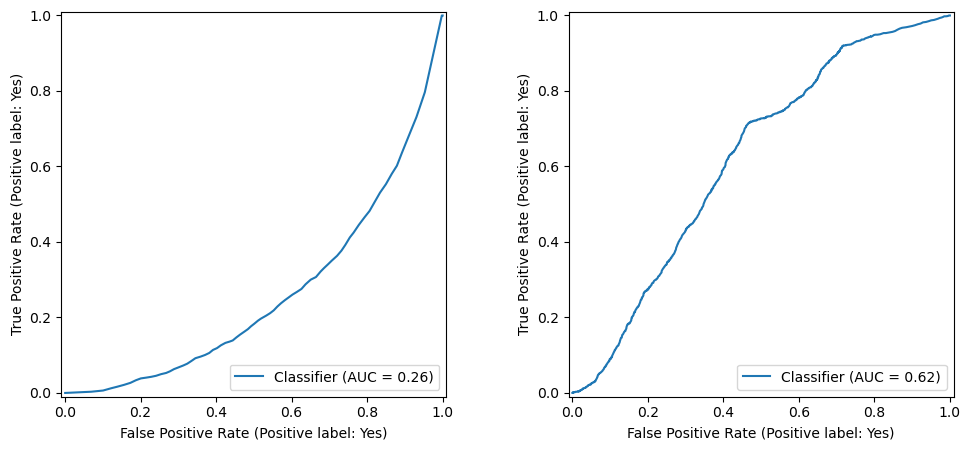

In [17]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 5)
RocCurveDisplay.from_predictions(y_true=raw_data["Churn"], y_score=raw_data["tenure"], ax=ax[0], pos_label="Yes")
RocCurveDisplay.from_predictions(y_true=raw_data["Churn"], y_score=raw_data["MonthlyCharges"], ax=ax[1], pos_label="Yes")

Both of these are impressive values, if we factor in that they are only single features. The tenure feature got a ROC-AUC of 0.26, but this just means that it's reverse is equivalent to a predictor with a ROC-AUC of 1 - 0.26 = 0.74.

# Outlier Search

The two numerical columns (monthly and total charges) can have outliers. These can be identified using absolute z-scores. Theoretically, the tenure column could also have outliers, but since we saw that it is strictly between 0 and 72 with a pretty uniform distribution, we won't search for outliers in that.

In [18]:
numeric_mean = raw_data[["MonthlyCharges", "TotalCharges"]].mean()
numeric_mean

MonthlyCharges      64.761692
TotalCharges      2283.300441
dtype: float64

In [19]:
numeric_std = raw_data[["MonthlyCharges", "TotalCharges"]].std()
numeric_std

MonthlyCharges      30.090047
TotalCharges      2266.771362
dtype: float64

In [20]:
absolute_z_scores = ((raw_data[["MonthlyCharges", "TotalCharges"]] - numeric_mean) / numeric_std).abs()
absolute_z_scores

,MonthlyCharges,TotalCharges
0,1.160241,0.994123
1,0.259611,0.173727
2,0.362635,0.959581
3,0.746482,0.195234
4,0.197351,0.940391
...,...,...
7038,0.665945,0.129171
7039,1.277443,2.240896
7040,1.168549,0.854453
7041,0.320315,0.872033


Count the ratio of potential outliers at different z-score thresholds.

In [21]:
for threshold in [1.0, 2.0, 2.5, 2.7, 3.0]:
    outlier_ratio_monthly_charges = np.mean(absolute_z_scores["MonthlyCharges"] > threshold)
    outlier_ratio_total_charges = np.mean(absolute_z_scores["TotalCharges"] > threshold)
    print(f"Ratio of MonthlyCharges outliers at a threshold of {threshold}: {outlier_ratio_monthly_charges:.5%}")
    print(f"Ratio of TotalCharges outliers at a threshold of {threshold}: {outlier_ratio_total_charges:.5%}")

Ratio of MonthlyCharges outliers at a threshold of 1.0: 43.16342%
Ratio of TotalCharges outliers at a threshold of 1.0: 19.30995%
Ratio of MonthlyCharges outliers at a threshold of 2.0: 0.00000%
Ratio of TotalCharges outliers at a threshold of 2.0: 5.59421%
Ratio of MonthlyCharges outliers at a threshold of 2.5: 0.00000%
Ratio of TotalCharges outliers at a threshold of 2.5: 1.27786%
Ratio of MonthlyCharges outliers at a threshold of 2.7: 0.00000%
Ratio of TotalCharges outliers at a threshold of 2.7: 0.29817%
Ratio of MonthlyCharges outliers at a threshold of 3.0: 0.00000%
Ratio of TotalCharges outliers at a threshold of 3.0: 0.00000%


It seems that there aren't any monthly charge data elements that fall outside of the 2 sigma range. In contrast, 0.3% of the total charges data elements fall outside of the 2.7 sigma range. Look at these few outliers in the dataset!

In [22]:
raw_data[absolute_z_scores["TotalCharges"] > 2.7]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
437,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,No
464,1480-BKXGA,Male,1,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),116.05,8404.90,No
850,6007-TCTST,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),115.80,8476.50,No
2025,1488-PBLJN,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),116.85,8477.70,No
2115,8984-HPEMB,Female,0,No,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.65,8477.60,No
2187,8879-XUAHX,Male,0,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,116.25,8564.75,No
2368,6650-BWFRT,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),117.15,8529.50,No
2559,8263-QMNTJ,Male,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8425.30,No
2603,0164-APGRB,Female,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,114.90,8496.70,No
2667,8454-AATJP,Female,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),115.05,8405.00,No


These customers all have a really high tenure, have phone services, multiple lines, fiber optic connections, online security, etc..., i.e. they bought almost every possible product. And only one of them churned! Although they are indeed outliers according to their total charge values, they provide useful information and should not be thrown away!

# Dimensionality Reduction

This table mostly contains categorical data, meaning that most of the classical dimensionality reduction techniques are not the best for its analysis. PCA assumes a Gaussian distribution in the high dimensional space, which cannot be true for categorical data. tSNE calculates Euclidean distances between datapoints, which is not suitable for one-hot encoded features. However, after a little digging, I discovered the technique __Multiple Correspondence Analysis__ or MCA, designed exactly for this type of tables. It can be used from the __prince__ Python package (`pip install prince`). It is based on the SVD decomposition of a transformed version of the raw categorical encodings.

But our first job is to convert the categorical data to one-hot encoded features.

In [23]:
one_hot_encoders = dict()
categorical_encodings = dict()
for column_name, percentages in categorical_columns.items():

    unique_values = list(percentages.keys())
    one_hot_encoders[column_name] = unique_values

    # If only two options are in a column, then use simple binary encoding.
    # If it is a Yes-No column, encode Yes as 1 and No as 0.
    if set(unique_values) == {"Yes", "No"}:
        uv_column_name = f"{column_name}:Yes"
        categorical_encodings[uv_column_name] = raw_data[column_name] == "Yes"
        continue
        
    # Other two-option columns can be assigned arbitrarily.
    if len(unique_values) == 2:
        uv_column_name = f"{column_name}:{unique_values[0]}"
        categorical_encodings[uv_column_name] = raw_data[column_name] == unique_values[0]
        continue

    # Else use one-hot encoding.
    for uv in unique_values:
        uv_column_name = f"{column_name}:{uv}"
        categorical_encodings[uv_column_name] = raw_data[column_name] == uv
        
categorical_encodings = pd.DataFrame(categorical_encodings, dtype=int)
categorical_encodings

,gender:Female,Partner:Yes,Dependents:Yes,PhoneService:Yes,MultipleLines:No,MultipleLines:No phone service,MultipleLines:Yes,InternetService:DSL,InternetService:Fiber optic,InternetService:No,...,Contract:Month-to-month,Contract:One year,Contract:Two year,PaperlessBilling:Yes,PaymentMethod:Bank transfer (automatic),PaymentMethod:Credit card (automatic),PaymentMethod:Electronic check,PaymentMethod:Mailed check,Churn:Yes,SeniorCitizen:0
0,1,1,0,0,0,1,0,1,0,0,...,1,0,0,1,0,0,1,0,0,1
1,0,0,0,1,1,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,1
2,0,0,0,1,1,0,0,1,0,0,...,1,0,0,1,0,0,0,1,1,1
3,0,0,0,0,0,1,0,1,0,0,...,0,1,0,0,1,0,0,0,0,1
4,1,0,0,1,1,0,0,0,1,0,...,1,0,0,1,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,1,0,0,1,1,0,0,...,0,1,0,1,0,0,0,1,0,1
7039,1,1,1,1,0,0,1,0,1,0,...,0,1,0,1,0,1,0,0,0,1
7040,1,1,1,0,0,1,0,1,0,0,...,1,0,0,1,0,0,1,0,0,1
7041,0,1,0,1,0,0,1,0,1,0,...,1,0,0,1,0,0,0,1,1,0


Now, let's use the MCA class in prince to perform dimensionality reduction on our one-hot encoded dataset. Pay attention that we have to remove the Churn target column and use it later only for coloring.

In [24]:
import prince
mca = prince.MCA(
    n_components=15, 
    one_hot=False
)
dim_red_data = mca.fit_transform(categorical_encodings.drop(columns=["Churn:Yes"]))
dim_red_data = dim_red_data.values
print(dim_red_data.shape)

(7043, 15)


Look at the eigenvalues of the selected components.

In [25]:
mca.eigenvalues_summary[:5]

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.548,31.79%,31.79%
1,0.199,11.56%,43.35%
2,0.146,8.48%,51.83%
3,0.084,4.88%,56.71%
4,0.075,4.35%,61.06%


Text(0, 0.5, 'Cumulative Explained Variance')

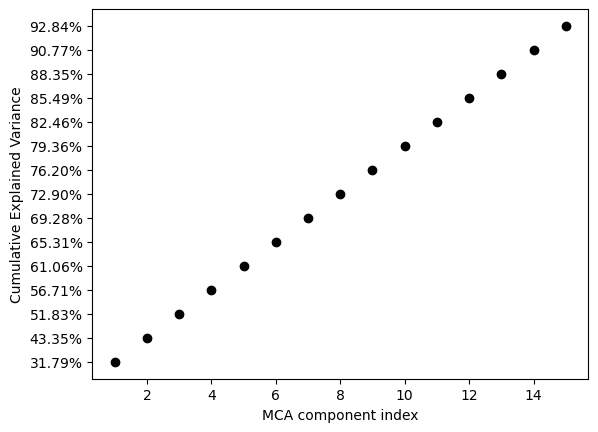

In [26]:
fig, ax = plt.subplots()
ax.scatter(
    mca.eigenvalues_summary.index + 1,
    mca.eigenvalues_summary["% of variance (cumulative)"],
    color="black"
)
ax.set_xlabel("MCA component index")
ax.set_ylabel("Cumulative Explained Variance")

It seems like that the first component explains about 32% of the overall variance. After that, the cumulative explained variance rises linearly. This means that most of the components are pretty uncorrelated, because each increments the cumulative explained variance with an equal amount.

Next, look at the contribution of each feature to the first, most important component.

In [27]:
mca.column_contributions_[0].sort_values()[:-15:-1]

OnlineSecurity:No internet service      0.104276
StreamingTV:No internet service         0.104276
TechSupport:No internet service         0.104276
DeviceProtection:No internet service    0.104276
StreamingMovies:No internet service     0.104276
OnlineBackup:No internet service        0.104276
InternetService:No                      0.104276
OnlineSecurity:No                       0.020757
TechSupport:No                          0.020705
InternetService:Fiber optic             0.017806
DeviceProtection:No                     0.017629
OnlineBackup:No                         0.017501
StreamingTV:No                          0.015129
StreamingMovies:No                      0.014900
Name: 0, dtype: float64

It seems that the presence of an internet service is a high variability indicator in this dataset. This information is redundantly contained within the "StreamingTV", "TechSupport", "DeviceProtection", "StreamingMovies", "OnlineSecurity", "InternetService" and "OnlineBackup" columns. Second to this information, the "OnlineSecurity:No" and "TechSupport:No" columns are also important.

Now, let's create a visualization for the transformed datapoints.

Text(0.5, 1.0, 'Multiple Correspondence Analysis on the\nCategorical Columns of the TELCO Dataset')

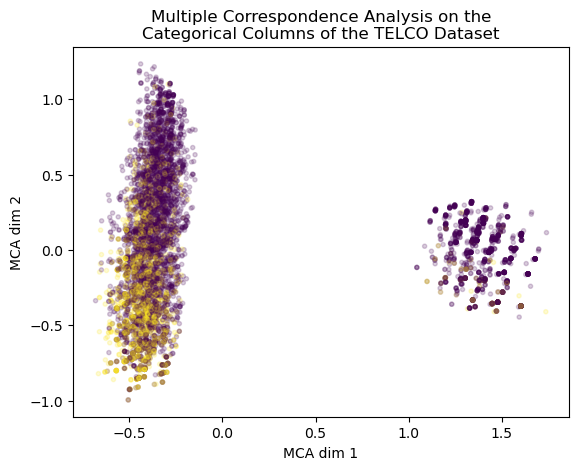

In [28]:
fig, ax = plt.subplots()
ax.scatter(
    dim_red_data[:, 0], dim_red_data[:, 1],
    c=categorical_encodings["Churn:Yes"],
    marker=".", alpha=0.2
)
ax.set_xlabel("MCA dim 1")
ax.set_ylabel("MCA dim 2")
ax.set_title("Multiple Correspondence Analysis on the\nCategorical Columns of the TELCO Dataset")

Now this is interesting; the MCA 2D projection separates datapoints into two very visible clusters. However, this separation is not really useful for churn prediction, because both clusters contain mixed customer types "churning-wise". Furthermore, on the larger pointcloud on the left, we can see a clear gradient in customer churning; the lover the second MCA dimension, the more likely that the customer leaves the company! Let's see if a 3D projection helps in separation.

Text(0.5, 0.92, 'Multiple Correspondence Analysis on the\nCategorical Columns of the TELCO Dataset')

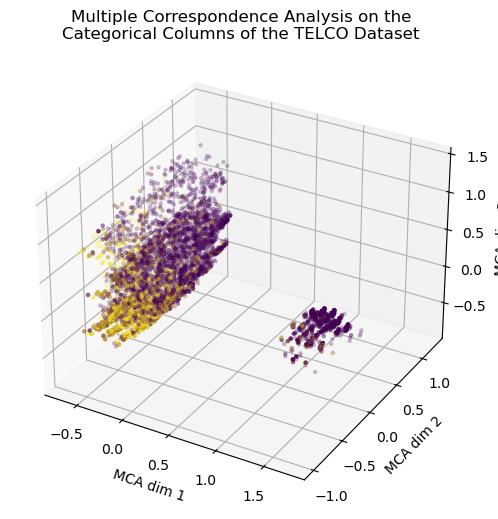

In [29]:
fig, ax = plt.subplots(subplot_kw=dict(projection="3d"))
fig.set_size_inches(6, 6)
ax.scatter(
    dim_red_data[:, 0], dim_red_data[:, 1], dim_red_data[:, 2],
    c=categorical_encodings["Churn:Yes"],
    marker=".", alpha=0.2
)
ax.set_xlabel("MCA dim 1")
ax.set_ylabel("MCA dim 2")
ax.set_zlabel("MCA dim 3")
ax.set_title("Multiple Correspondence Analysis on the\nCategorical Columns of the TELCO Dataset")

The third component doesn't seem to really help. Now, lets investigate the separation power of the individual dimensions!

[<Figure size 1000x500 with 2 Axes>,
 <Figure size 1000x500 with 2 Axes>,
 <Figure size 1000x500 with 2 Axes>]

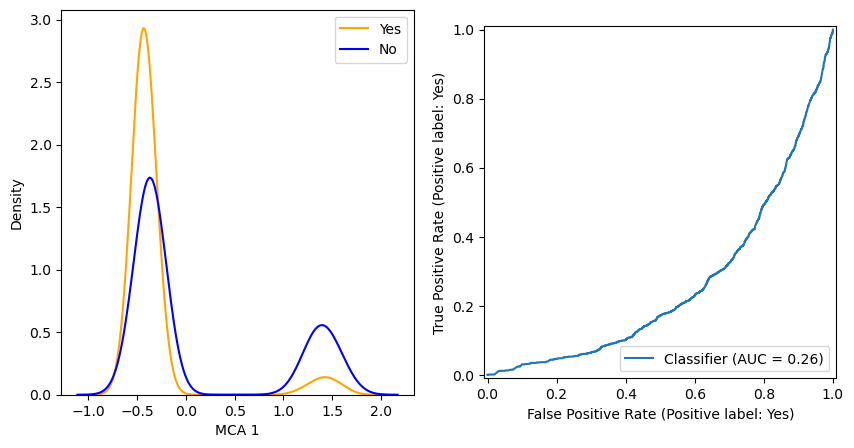

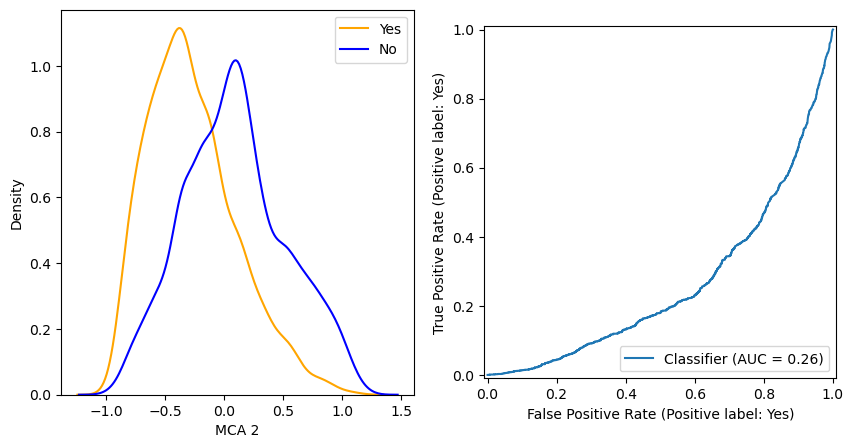

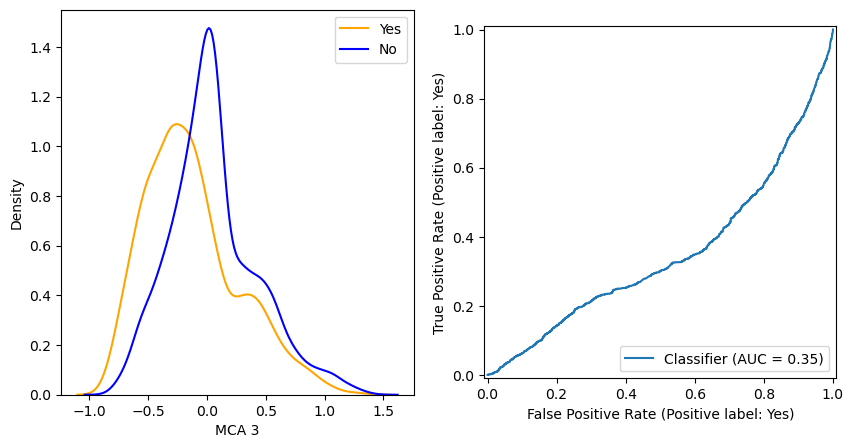

In [30]:
dim_red_separation_figs = list()
for dim_idx in range(3):

    # Figure settings
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(10, 5)

    # Axis 0 plotting: KDE density plots
    sns.kdeplot(dim_red_data[raw_data["Churn"] == "Yes", dim_idx], color="orange", ax=ax[0], label="Yes")
    sns.kdeplot(dim_red_data[raw_data["Churn"] == "No", dim_idx], color="blue", ax=ax[0], label="No")
    ax[0].set_xlabel(f"MCA {dim_idx + 1}")
    ax[0].legend(loc="upper right")

    # Axis 1 plotting: ROC-AUC calculations for the individual MCA dimensions.
    RocCurveDisplay.from_predictions(y_true=raw_data["Churn"], y_score=dim_red_data[:, dim_idx], ax=ax[1], pos_label="Yes")
    
    dim_red_separation_figs.append(fig)
dim_red_separation_figs

# Summary

So, to summarize, we learned the following things with respect to this dataset:

- it is a telecommunication company dataset containing customer features (e.g. services used, loyalty time, etc..) and the goal is to predict customer churning,
- in total, the table contains 7043 rows and 21 columns, out of which 1 is the target column and 1 is a customer ID column (not useful for prediction),
- 16 + 1 categorical columns, and 3 numerical columns can be identified (not counting the ID column),
- out of the 3 numerical columns, 1 is of type integer (tenure), while the other 2 are floats (monthly and total charges),
- in the total charges column, there are 11 only-space values, which represent NaN values,
- a lot of categorical features, such as the contract type feature, are already very good indicators for churning,
- the tenure column has an approximately uniform distribution (with elevated densities at the domain ends), the monthly charges column is multimodal, while the total charges follows either an exponential or a power-law distribution,
- the tenure value creates linear boundaries for the total charges column,
- customers with a high tenure value are unlikely to churn (ROC-AUC = 0.74),
- customers with low monthly charges are unlikely to churn (ROC-AUC = 0.62),
- only the total charges feature contains outlier values (z-score > 2.7), but these should be kept, because they provide useful information and are not erroneous datapoints,
- due to the large number of categorical features, Multiple Correspondence Analysis (MCA) is best suited for dimensionality reduction,
- the information of whether a customer has internet survice or not is contained redundantly in multiple columns,
- other categorical columns add equal total variances to the MCA, meaning that all categorical features should be used for training, due to their approximate orthogonality,
- churn separation along the first two MCA components works fairly well (ROC-AUC of 0.74 and 0.74, respectively).